In [3]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install shap

   ---------------------------------------- 0.0/456.2 kB ? eta -:--:--
   ----- ---------------------------------- 61.4/456.2 kB 3.4 MB/s eta 0:00:01
   ----------------- ---------------------- 204.8/456.2 kB 3.1 MB/s eta 0:00:01
   -------------------- ------------------- 235.5/456.2 kB 2.4 MB/s eta 0:00:01
   ----------------------- ---------------- 266.2/456.2 kB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 266.2/456.2 kB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 266.2/456.2 kB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 266.2/456.2 kB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 266.2/456.2 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------  450.6/456.2 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 456.2/456.2 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install cvxpy

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------ --------------------------------- 0.2/1.1 MB 5.3 MB/s eta 0:00:01
   ---------------------- ----------------- 0.6/1.1 MB 7.6 MB/s eta 0:00:01
   ----------------------------------- ---- 0.9/1.1 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 6.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/736.4 kB ? eta -:--:--
   --------------------- ------------------ 389.1/736.4 kB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 736.4/736.4 kB 7.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/72.2 kB ? eta -:--:--
   ---------------------------------------- 72.2/72.2 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/293.5 kB ? eta -:--:--
   ------------------------------------ --- 266.2/293.5 kB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 293.5/293.5 kB 6.0 MB/s eta 0:00:00
   --------------

In [5]:
pip install ta --upgrade

[*********************100%%**********************]  1 of 1 completed
C:\Users\adams\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adams\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - loss: 1506.1709 - val_loss: 1872.1251
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1503.9895 - val_loss: 1867.3447
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1517.4583 - val_loss: 1862.0645
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1466.1635 - val_loss: 1855.8575
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1476.4683 - val_loss: 1847.3113
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1493.9601 - val_loss: 1835.7534
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1443.4268 - val_loss: 1821.2168
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1432.6840 - val_loss: 1799.5996
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1409.4167 - val_loss: 1768.7429
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1388.2222 - val_loss: 1726.4307
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1349.8898 - val_loss: 1667.2451
Epoch 12/20
5/5 ━━

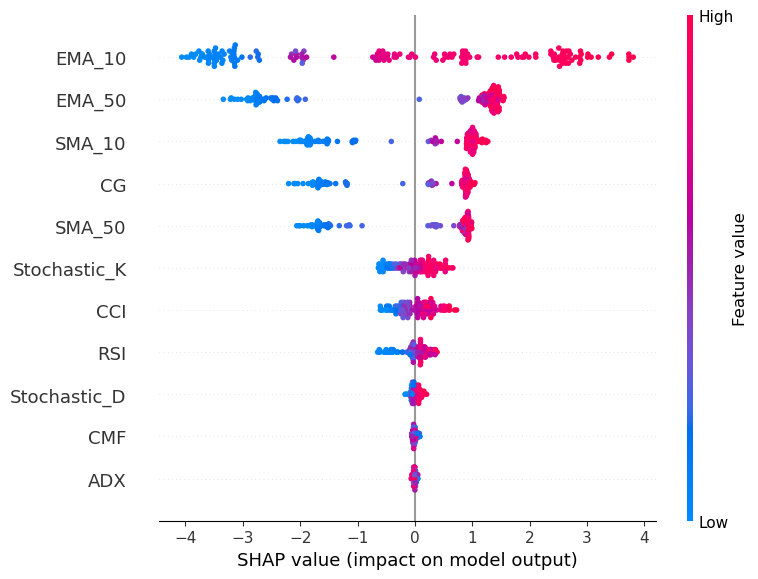

INFO:root:Script completed successfully.


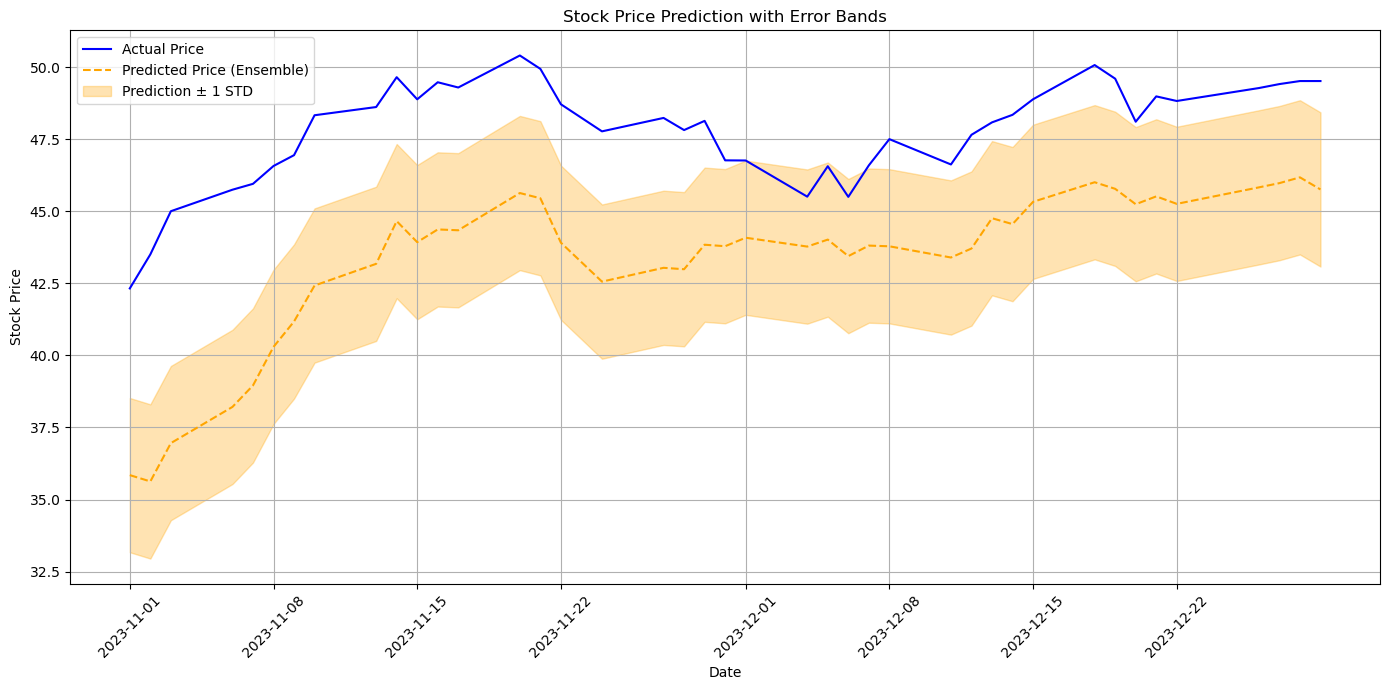

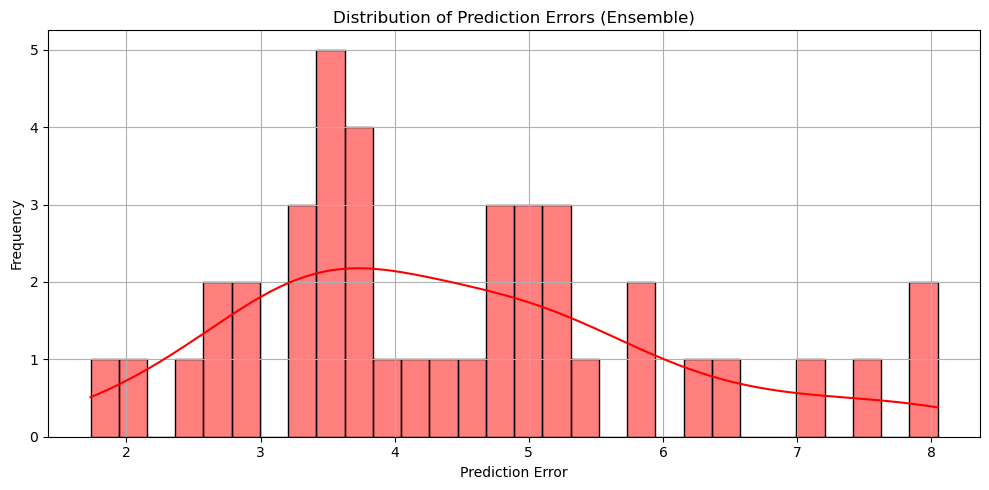

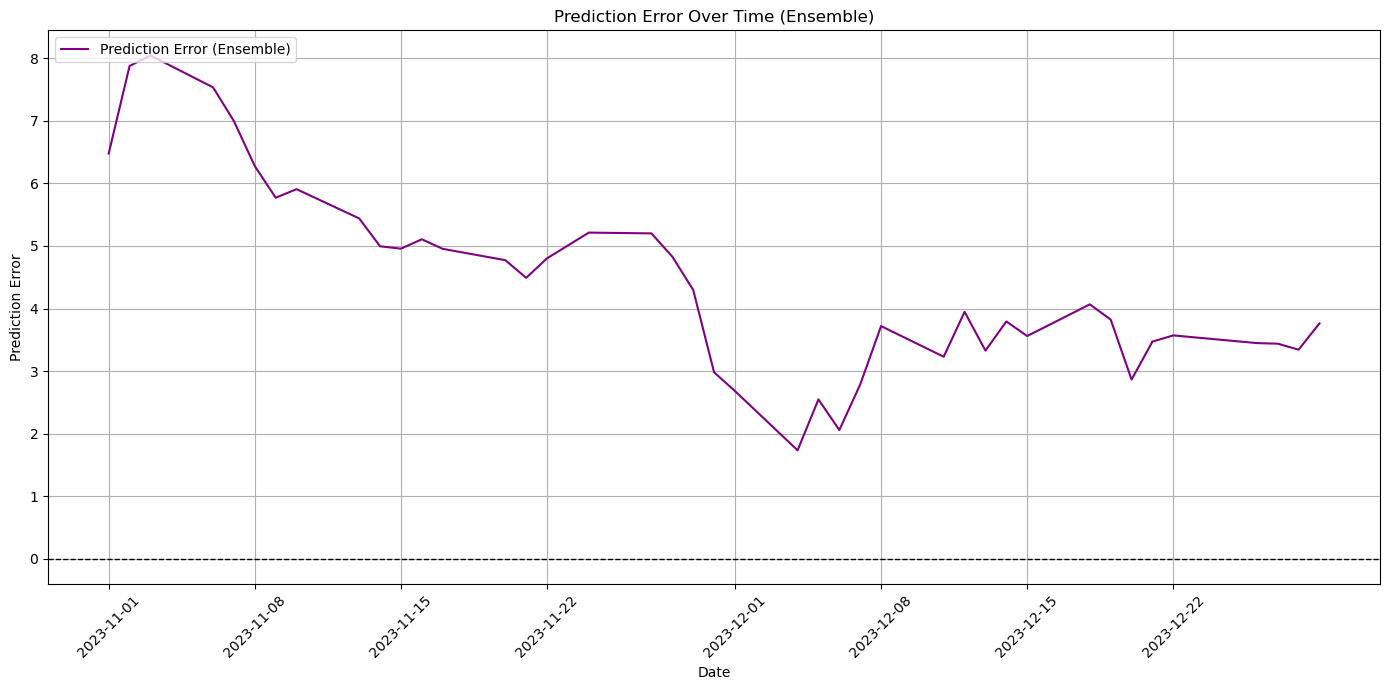

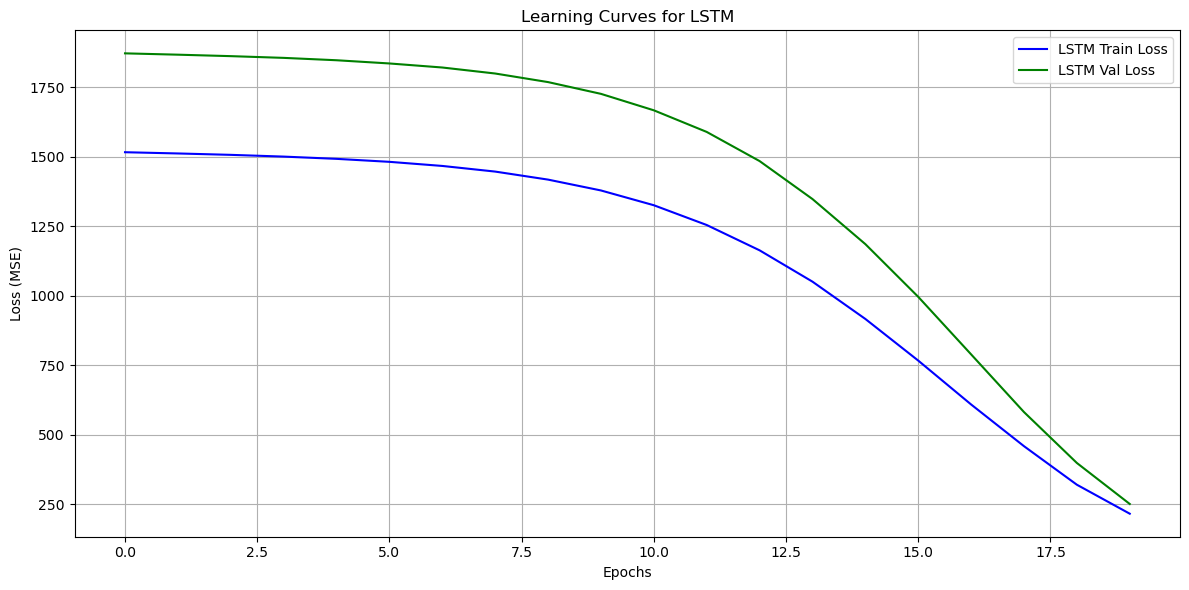

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import SMAIndicator, EMAIndicator, ADXIndicator, CCIIndicator
from ta.volume import ChaikinMoneyFlowIndicator
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import logging

# Setup logging
logging.basicConfig(level=logging.INFO)

# Fetch stock data using Yahoo Finance
ticker_symbol = 'NVDA'
stock_data = yf.download(ticker_symbol, start='2023-01-01', end='2024-01-01')

# Feature Engineering with Indicators
def add_indicators(data):
    # Simple Moving Averages
    data['SMA_10'] = SMAIndicator(data['Close'], window=10).sma_indicator()
    data['SMA_50'] = SMAIndicator(data['Close'], window=50).sma_indicator()

    # Exponential Moving Averages
    data['EMA_10'] = EMAIndicator(data['Close'], window=10).ema_indicator()
    data['EMA_50'] = EMAIndicator(data['Close'], window=50).ema_indicator()

    # Average Directional Index
    data['ADX'] = ADXIndicator(data['High'], data['Low'], data['Close'], window=14).adx()

    # Accumulative Swing Index
    # ASI is a more complex formula; we will use it from the TA library
    # but it's not directly available in the 'ta' package. Hence, we'll leave it out.
    # If necessary, custom code for ASI can be added based on its formula.

    # Centre of Gravity (CG) - This is also available from the 'ta' package
    data['CG'] = data['Close'].rolling(window=14).mean()  # Example of a simple CG

    # Chaikin Money Flow
    data['CMF'] = ChaikinMoneyFlowIndicator(data['High'], data['Low'], data['Close'], data['Volume']).chaikin_money_flow()

    # Commodity Channel Index
    data['CCI'] = CCIIndicator(data['High'], data['Low'], data['Close'], window=20).cci()

    # Relative Strength Index
    data['RSI'] = RSIIndicator(data['Close'], window=14).rsi()

    # Stochastic Oscillator
    stochastic = StochasticOscillator(data['High'], data['Low'], data['Close'], window=14, smooth_window=3)
    data['Stochastic_K'] = stochastic.stoch()
    data['Stochastic_D'] = stochastic.stoch_signal()

    return data

# Add indicators to the stock data
stock_data = add_indicators(stock_data)

# Remove NaN values
stock_data = stock_data.dropna()

# Define features and target
features = [
    'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 'ADX', 
    'CG', 'CMF', 'CCI', 'RSI', 'Stochastic_K', 
    'Stochastic_D'
]
X = stock_data[features]
y = stock_data['Close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_model.predict(X_test_scaled)

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Neural Network (MLP Regressor)
mlp_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

# LSTM Model
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(25))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
history_lstm = lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Ensemble Prediction
y_pred_ensemble = (y_pred_lr + y_pred_rf + y_pred_mlp + y_pred_lstm) / 4

# Performance Metrics
def print_metrics(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

print_metrics(y_test, y_pred_lr, "Linear Regression")
print_metrics(y_test, y_pred_rf, "Random Forest")
print_metrics(y_test, y_pred_mlp, "MLP Regressor")
print_metrics(y_test, y_pred_lstm, "LSTM")
print_metrics(y_test, y_pred_ensemble, "Ensemble")

# Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse = cross_val_score(rf_model, X, y, cv=kfold, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_mse)
print(f"Random Forest Cross-Validated RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

# SHAP for feature importance (Random Forest model)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_scaled)
shap.summary_plot(shap_values, X_train, feature_names=features)

# Plotting Predictions vs Actual
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Price', color='blue')
plt.plot(y_test.index, y_pred_ensemble, label='Predicted Price (Ensemble)', linestyle='--', color='orange')
plt.fill_between(y_test.index, y_pred_ensemble - np.std(y_pred_ensemble), y_pred_ensemble + np.std(y_pred_ensemble), color='orange', alpha=0.3, label='Prediction ± 1 STD')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction with Error Bands')
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Distribution of Errors
errors_ensemble = y_test - y_pred_ensemble
plt.figure(figsize=(10, 5))
sns.histplot(errors_ensemble, bins=30, kde=True, color='red')
plt.title('Distribution of Prediction Errors (Ensemble)')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()

# Time series of errors
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, errors_ensemble, label='Prediction Error (Ensemble)', color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Prediction Error')
plt.title('Prediction Error Over Time (Ensemble)')
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Learning Curves
plt.figure(figsize=(12, 6))
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss', color='blue')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss', color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves for LSTM')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

# Logging completion
logging.info('Script completed successfully.')

# Display all the plots
plt.show()
